In [1]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..'))
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from scripts import material_params as mat
from scipy.linalg import eigh
import plotly.graph_objects as go
from scripts import FDD as fdd
from scipy.optimize import differential_evolution


In [ ]:
param_space2D_fixed = np.load('../05model_updating/param_spaces/param_space2D_fixed.npy')
eigvecs2D_fixed = np.load('../05model_updating/param_spaces/param_space_eigvecs2D_fixed.npy')


## **Randomly chosen set of parameters from the 2D parameter space**

this will act as the modelled natural frequencies!!

In [3]:
np.random.seed(1)  # Set a seed for reproducibility


N = 100

idx_kf = np.random.randint(0, N, 1)[0]
idx_Iy = np.random.randint(0, N, 1)[0]

idx_kf = 0
idx_Iy = -1
print(f"Randomly selected indices: idx_kf={idx_kf}, idx_Iy={idx_Iy}")

# Corresponding parameter values
kf_min, kf_max = 5e6, 5e7
Iy_min, Iy_max = 100, 2000
kl_min, kl_max = 0.2e10, 1e10

kf_vals = np.arange(kf_min, kf_max, (kf_max - kf_min) / N)
Iy_vals = np.arange(Iy_min, Iy_max, (Iy_max - Iy_min) / N)

print(f"Selected parameter values: kf={kf_vals[idx_kf]}, Iy={Iy_vals[idx_Iy]}")

# Corresponding eigenvalues and eigenvectors
eigvals_selected = param_space2D_fixed[idx_kf, idx_Iy]
eigvecs_selected = eigvecs2D_fixed[idx_kf, idx_Iy]

print(f"Selected eigenvalues: {eigvals_selected}")



Randomly selected indices: idx_kf=0, idx_Iy=-1
Selected parameter values: kf=5000000.0, Iy=1981.0
Selected eigenvalues: [0.75151253 1.01273139 1.39460456 1.06623768 1.42815727 1.51309843]


## **Identified natural frequencies and mode shapes using 22 sensors and initial baseline model**

In [90]:
f_identified = [0.500, 0.647, 1.501, 1.514]
eigvecs_identified = np.load('phi_experiment_26_sensors.npy')

f_identified = f_identified[:4]
eigvecs_identified = eigvecs_identified[:, :4]


## **Reducing modelled eigenvectors to the same ndof as indentified eigenvectors**

In [91]:
selected_dofs = []
node_numbers = [1, 2, 3, 4, 8, 12, 16, 19, 21, 27, 31, 35 , 
                38, 40, 46, 49, 55, 58, 70, 75, 94, 113]
for i in range(len(node_numbers)):
    if node_numbers[i] <75:
        selected_dofs.extend([node_numbers[i]*6 + j for j in range(3)])
    else:
        selected_dofs.extend([node_numbers[i]*6+j for j in range(3)])
# selected_dofs = [node*6-3 + i for node in node_numbers for i in range(3)]  # Example: DOFs of node 13 (x, y, z)


eigvecs_reduced = eigvecs_selected[selected_dofs, :4] 
eigvals_reduced = eigvals_selected[:4]




print(eigvecs_reduced.shape == eigvecs_identified.shape)  # Should be True

n_modes = eigvecs_reduced.shape[1]
print(eigvals_reduced)

True
[0.75151253 1.01273139 1.39460456 1.06623768]


## **Initial MAC matrix before updating**

c:\Users\alami\Desktop\MSc-thesis---minimal-FEM-model-of-the-Maeslantkering\scripts\FDD.py:118: ComplexWarning: Casting complex values to real discards the imaginary part
  MAC[i, j] = num / den


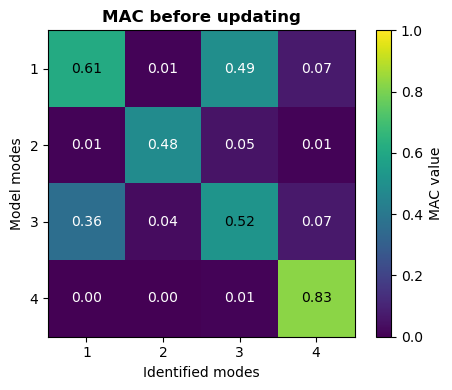

In [92]:
fdd.plot_mac(fdd.compute_mac(eigvecs_reduced, eigvecs_identified, n_modes = n_modes), title='MAC before updating', xlabel='Identified modes', ylabel='Model modes')

## **Applying the objective function algorithm**

In [ ]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator



# ==========================================================
# LOAD DATABASE
# ==========================================================

param_space = np.load("param_space2D.npy")            # (Nkf, NIy, nmodes)
param_modes = np.load("param_space_eigvecs2D.npy")    # (Nkf, NIy, ndof, nmodes)

# ==========================================================
# PARAMETER GRIDS
# ==========================================================

kf_vals = np.linspace(5e6, 5e7, param_space.shape[0])
Iy_vals = np.linspace(100, 2000, param_space.shape[1])

# ==========================================================
# USER CONTROLS
# ==========================================================

COARSE_GRID = 60      # Initial global search
REFINE_GRID = 150     # Grid used during refinements
N_REFINE = 3          # Number of refinement levels

# ==========================================================
# EXPERIMENTAL DATA
# ==========================================================

f_meas = np.array(f_identified)

phi_meas = eigvecs_identified[:, :len(f_meas)]
phi_meas = phi_meas / np.linalg.norm(phi_meas, axis=0, keepdims=True)

n_modes = len(f_meas)

# ==========================================================
# SENSOR DOF SELECTION
# ==========================================================

selected_dofs = []

node_numbers = [
    1, 2, 3, 4, 8, 12, 16, 19, 21, 27, 31,
    35, 38, 40, 46, 49, 55, 58, 70, 75, 94, 113
]

for node in node_numbers:
    if node < 75:
        selected_dofs.extend([node * 6 + j for j in range(3)])
    else:
        selected_dofs.extend([node * 6 - 2 + j for j in range(3)])

selected_dofs = np.array(selected_dofs)

# ==========================================================
# MAC FUNCTION
# ==========================================================

def MAC(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()

    return (np.abs(np.vdot(a, b))**2) / (
        np.vdot(a, a) * np.vdot(b, b)
    )

# ==========================================================
# SURROGATE INTERPOLATORS
# ==========================================================

freq_interp = RegularGridInterpolator(
    (kf_vals, Iy_vals),
    param_space,
    bounds_error=False,
    fill_value=None
)

mode_interp = RegularGridInterpolator(
    (kf_vals, Iy_vals),
    param_modes.reshape(len(kf_vals), len(Iy_vals), -1),
    bounds_error=False,
    fill_value=None
)

# ==========================================================
# OBJECTIVE FUNCTION
# ==========================================================

def objective(kf, Iy):

    f_pred = freq_interp((kf, Iy))

    phi_full = mode_interp((kf, Iy)).reshape(
        -1,
        param_space.shape[2]
    )

    f_pred = f_pred[:n_modes]

    phi_pred = phi_full[:, :n_modes]

    phi_pred = phi_pred[selected_dofs, :]
    phi_pred = phi_pred / np.linalg.norm(
        phi_pred,
        axis=0,
        keepdims=True
    )

    # Frequency contribution
    freq_term = np.sum(
        ((f_pred - f_meas) / f_meas) ** 2
    )

    # MAC contribution
    mode_term = 0.0

    for r in range(n_modes):
        mode_term += 1.0 - MAC(
            phi_pred[:, r],
            phi_meas[:, r]
        )

    # Increase frequency weight if desired
    return 10.0 * freq_term + mode_term


# ==========================================================
# MULTI-LEVEL GRID SEARCH
# ==========================================================

kf_min = kf_vals.min()
kf_max = kf_vals.max()

Iy_min = Iy_vals.min()
Iy_max = Iy_vals.max()

best_val = np.inf
best_kf = None
best_Iy = None



for level in range(N_REFINE):

    if level == 0:
        Nkf = COARSE_GRID
        NIy = COARSE_GRID
    else:
        Nkf = REFINE_GRID
        NIy = REFINE_GRID

    kf_grid = np.linspace(kf_min, kf_max, Nkf)
    Iy_grid = np.linspace(Iy_min, Iy_max, NIy)

    print(f"\nSearching level {level+1}...")

    for kf in kf_grid:
        for Iy in Iy_grid:

            val = objective(kf, Iy)

            if val < best_val:

                best_val = val
                best_kf = kf
                best_Iy = Iy

    print(f"Best objective : {best_val:.6e}")
    print(f"kf             : {best_kf:.3f}")
    print(f"Iy             : {best_Iy:.3f}")

    # ------------------------------------------------------
    # Shrink search window around optimum
    # ------------------------------------------------------

    kf_width = (kf_max - kf_min) / 4
    Iy_width = (Iy_max - Iy_min) / 4

    kf_min = max(kf_vals.min(), best_kf - kf_width / 2)
    kf_max = min(kf_vals.max(), best_kf + kf_width / 2)

    Iy_min = max(Iy_vals.min(), best_Iy - Iy_width / 2)
    Iy_max = min(Iy_vals.max(), best_Iy + Iy_width / 2)

# ==========================================================
# FINAL EVALUATION
# ==========================================================

kf_opt = best_kf
Iy_opt = best_Iy

f_opt = freq_interp((kf_opt, Iy_opt))

phi_opt = mode_interp((kf_opt, Iy_opt)).reshape(
    -1,
    param_space.shape[2]
)

f_opt = f_opt[:n_modes]

phi_opt = phi_opt[:, :n_modes]

phi_opt = phi_opt[selected_dofs, :]
phi_opt = phi_opt / np.linalg.norm(
    phi_opt,
    axis=0,
    keepdims=True
)

# ==========================================================
# RESULTS
# ==========================================================

print("\n==========================================")
print("        FEMU RESULT")
print("==========================================")

print(f"Best kf         = {kf_opt:.3f}")
print(f"Best Iy         = {Iy_opt:.3f}")
print(f"Objective value = {best_val:.6e}")

print("\nMeasured frequencies")
print(f_meas)

print("\nIdentified FEM frequencies")
print(f_opt)

print("\nMAC values")

for i in range(n_modes):
    print(
        f"Mode {i+1}: {MAC(phi_opt[:, i], phi_meas[:, i]):.5f}"
    )

print("==========================================")


Searching level 1...


C:\Users\alami\AppData\Local\Temp\ipykernel_16204\4273407243.py:167: ComplexWarning: Casting complex values to real discards the imaginary part
  objective_map[i, j] = val


Best objective : 7.978896e-01+0.000000e+00j
kf             : 8813559.322
Iy             : 325.424

Searching level 2...
Best objective : 7.770141e-01+0.000000e+00j
kf             : 8484031.965
Iy             : 314.374

Searching level 3...
Best objective : 7.768229e-01+0.000000e+00j
kf             : 8460277.201
Iy             : 312.432

        FEMU RESULT
Best kf         = 8460277.201
Best Iy         = 312.432
Objective value = 7.768229e-01+0.000000e+00j

Measured frequencies
[0.5   0.647 1.501 1.514]

Identified FEM frequencies
[0.49678771 0.6537301  1.44879928 1.57110965]

MAC values
Mode 1: 0.80280+0.00000j
Mode 2: 0.69587+0.00000j
Mode 3: 0.91608+0.00000j
Mode 4: 0.83624+0.00000j


In [95]:
# kf_opt = 10000000
# Iy_opt = 390

## **Running the model with updated parameters**

In [96]:
nodes = []
nodal_values = np.loadtxt('../text_files/nodes_minimal_model.txt', delimiter=',')
for i in range(nodal_values.shape[0]):
  nodes.append(n.nodes(nodal_values[i, 0], nodal_values[i, 1], nodal_values[i, 2]))

In [97]:

def effective_truss_stiffness(d1, d2,t1, t2, h, b, res): 
    '''Calculates equivalent moment of inertia and area to be used in a Timoshenko beam model

    Inputs:

    d1: Diameter of the diagonal truss elements
    d2: Diameter of the horizontal truss elements
    t1: Thickness of the diagonal truss elements
    t2: Thickness of the horizontal truss elements
    h: Height of the truss
    b: Width of the truss
    z_NC: Distance from the neutral axis to the centroid of the truss elements

    returns:
    A_eq: Effective area of the truss
    I_eqy: Effective moment of inertia around the y-axis (strong axis)
    I_eqz: Effective moment of inertia around the z-axis (weak axis)
    b_eq: Effective width of the truss for shear deformation calculations
    h_eq: Effective height of the truss for shear deformation calculations
    '''
    
    A1 = np.pi * (d1/2)**2 - np.pi * ((d1/2) - 2 * t1)**2
    A2 = np.pi * (d2/2)**2 - np.pi * ((d2/2) - 2 * t2)**2

    z_NC = (A2 * 0 +  2 * h * A2) / (3 * A2)
    y_NC = (A2 * 0 + A2 * 0.5 * b + A2 * b) / (3 * A2)
    I = (np.pi / 4) * ((d2/2)**4 - ((d2/2) - t2)**4)
    Iy_eq = I + A2 * z_NC**2 + 2 * (I + A2 * (h - z_NC)**2)
    Iz_eq = I + A2 * y_NC**2 + I + A2 * (0.5 * b - y_NC)**2 + I + A2 * (b - y_NC)**2
    A_eq = A1 * 5 + A2 * 3
    b_eq  = ((Iz_eq**3) / (Iy_eq* (1/12)**2))**(1/8)
    h_eq = Iz_eq / ((1/12)* b_eq**3)

    Iy_eq = res #390
    Iz_eq = 0.4*Iy_eq
    b_eq  = ((Iz_eq**3) / (Iy_eq* (1/12)**2))**(1/8)
    h_eq = Iz_eq / ((1/12)* b_eq**3)
    A_eq = A1 * 5 + A2 * 3
    



    return A_eq, Iy_eq, Iz_eq, b_eq, h_eq


E = 210e9  # Young's modulus in Pascals
nu = 0.3   # Poisson's ratio
G = E / (2 * (1 + nu))  # Shear modulus in Pascals
m = 6.7504 * 10 ** 6 #kg
m = 5596024
d1 = 0.8 #m
d2 = 1.8 #m
t1 = 0.03 #m
t2 = 0.08 #m
L_truss_element_y = 15 #m
h_truss = 18 #m
Aeq, Ieqy, Ieqz, b_eq, h_eq = effective_truss_stiffness(d1, d2, t1, t2, h_truss, L_truss_element_y, Iy_opt) 
L = 237.5
rho_truss = m / (L * Aeq)
It = (b_eq * h_eq**3 / 3) * (1 - 0.63 * (h_eq / b_eq) * (1 - (h_eq**4 / (12 * b_eq**4)))) *0.06
k = 0.08
Ip  = Ieqy + Ieqz
ep_K = [E, G, Aeq, Ieqy, Ieqz, It, k]
ep_m = [rho_truss, Aeq, Ieqy, Ieqz, Ip]

In [98]:
k = 5/6
rho = 7850 #kg/m^3
E=210e9 #Pa
G = E/(2*(1+nu)) #Pa
nu = 0.3 #Poisson's ratio
k_fender =  kf_opt
Iy_connect, Iz_connect, Ip_connect, It_connect, A_connect = mat.stiffness_connecting_beams()
ep_K_connect = [E, G, A_connect, Iy_connect, Iz_connect, It_connect, k]
ep_m_connect = [rho, A_connect, Iy_connect, Iz_connect, Ip_connect]

h_eq = 22
Iy_wall = 1250
Iz_wall = 0.25 * Iy_wall
Ip_wall = Iy_wall + Iz_wall
It_wall = 0.05 * Iy_wall
A_wall = Iy_wall * 12 / h_eq**2
m_wall = 6455148
L_wall = 237.5
rho_wall = m_wall / (L_wall * A_wall)
ep_K_wall = [E, G, A_wall, Iy_wall, Iz_wall, It_wall, k]
ep_m_wall = [rho_wall, A_wall, Iy_wall, Iz_wall, Ip_wall]


In [99]:

A_eq, Iy_eq, Iz_eq, b_eq, h_eq = mat.stiffness_connecting_truss(d1, d2, t1, t2, h_truss, L_truss_element_y)
Ip_connecting_truss = Iy_eq + Iz_eq 
It_eq = (b_eq * h_eq**3 / 3) * (1 - 0.63 * (h_eq / b_eq) * (1 - (h_eq**4 / (12 * b_eq**4)))) *0.06
ep_K_connecting_truss = [E, G, A_eq, Iy_eq, Iz_eq, It_eq, k]
ep_m_connecting_truss = [rho_truss, A_eq, Iy_eq, Iz_eq, Ip_connect]

In [100]:
# braces
k = 5/6
Iy, Iz, Ip, It, A = mat.stiffness_braces()
ep_K_braces = [E, G, A, Iy, Iz, It, k]
ep_m_braces = [rho, A, Iy, Iz, Ip]

In [101]:
elements = []
element_nodes = np.loadtxt('../text_files/element_nodes.txt', dtype=int)
for i in range(element_nodes.shape[0]):
    if element_nodes[i, 2] == 0:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K, ep_m))
    elif element_nodes[i, 2] == 1:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_wall, ep_m_wall))
    elif element_nodes[i, 2] == 2:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_connect, ep_m_connect))
    elif element_nodes[i, 2] == 3:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_connecting_truss, ep_m_connecting_truss))   
    elif element_nodes[i, 2] == 4:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_braces, ep_m_braces))
element_nodes = element_nodes[:, :2] # Remove the column with element type information


dofs = n.degrees_of_freedom(nodes)

element_locs = []

for (nA, nB) in element_nodes:
    dofs_A = dofs[f'dof_{nA}']
    dofs_B = dofs[f'dof_{nB}']
    element_locs.append(np.hstack((dofs_A, dofs_B)))



In [102]:
N = len(nodes)
DOFS_per_node = 6



K_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))
M_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))
print(K_global.shape    )

K_locs = []
M_locs = []



for i in range(len(element_locs)):
    K_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-1]
    M_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-2]



# To restore symmetry of the global stiffness and mass matrices
K_global = 0.5 * (K_global + K_global.T)
M_global = 0.5 * (M_global + M_global.T)



(1086, 1086)


In [103]:
# fender_dofs =  [70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 99,
#                100, 102, 104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124,
#                126, 128]
fender_dofs = [70, 75, 79, 83, 87, 91, 95, 99, 103, 107, 111, 115, 119, 123, 128]

k_fender_dofs = [dofs[f'dof_{i+1}'][2] for i in fender_dofs]
for dof in k_fender_dofs:
    K_global[dof, dof] += k_fender



In [104]:
indices_to_remove = np.hstack((dofs['dof_1'][0:3], dofs['dof_75'][0:2]))
keep_indices = np.setdiff1d(np.arange(N * DOFS_per_node), indices_to_remove)
K_global_reduced = K_global[np.ix_(keep_indices, keep_indices)]
M_global_reduced = M_global[np.ix_(keep_indices, keep_indices)]

In [105]:
eigvals_global, eigvecs_global = eigh(K_global_reduced, M_global_reduced)


tol = 1e-6
positive = eigvals_global > tol
eigvals_global = eigvals_global[positive]
eigvecs_global = eigvecs_global[:, positive]

frequencies_rad = np.sqrt(eigvals_global)
frequencies_hz = frequencies_rad / (2 * np.pi)


data_freqs = pd.DataFrame({
    'Frequency (Hz)': frequencies_hz,
    'Frequency (rad/s)': frequencies_rad
})

display(data_freqs[:15])


,Frequency (Hz),Frequency (rad/s)
0,0.459123,2.884758
1,0.599146,3.764544
2,1.404379,8.823971
3,1.452918,9.128952
4,1.571249,9.872447
5,1.827342,11.481531
6,2.174629,13.663595
7,2.286068,14.363787
8,2.560410,16.087533
9,3.242788,20.375039


In [106]:
eigvecs_full = e.expand_eigenvectors(eigvecs_global, keep_indices, N*DOFS_per_node)
print("Expanded eigenvectors shape:", eigvecs_global.shape)


Expanded eigenvectors shape: (1081, 1081)


In [107]:
eigvecs_disp_full = e.extract_displacement(eigvecs_full, keep=3, skip=3)
eigvecs_full.shape


(1086, 1081)

In [108]:
selected_dofs = []
node_numbers = [1, 2, 3, 4, 8, 12, 16, 19, 21, 27, 31, 35 , 
                38, 40, 46, 49, 55, 58, 70, 75, 94, 113]
for i in range(len(node_numbers)):
    if node_numbers[i] <75:
        selected_dofs.extend([node_numbers[i]*6 + j for j in range(3)])
    else:
        selected_dofs.extend([node_numbers[i]*6 + j for j in range(3)])
# selected_dofs = [node*6-3 + i for node in node_numbers for i in range(3)]  # Example: DOFs of node 13 (x, y, z)




eigvecs_new_reduced = eigvecs_full[selected_dofs, :4]
eigvals_new_reduced = eigvals_global[:4]


## **MAC matrix after Finite element model updating**

c:\Users\alami\Desktop\MSc-thesis---minimal-FEM-model-of-the-Maeslantkering\scripts\FDD.py:118: ComplexWarning: Casting complex values to real discards the imaginary part
  MAC[i, j] = num / den
c:\Users\alami\Desktop\MSc-thesis---minimal-FEM-model-of-the-Maeslantkering\scripts\FDD.py:118: ComplexWarning: Casting complex values to real discards the imaginary part
  MAC[i, j] = num / den


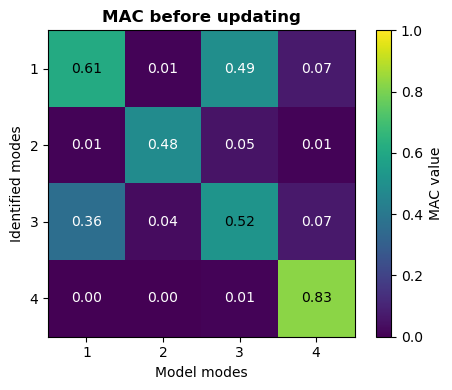

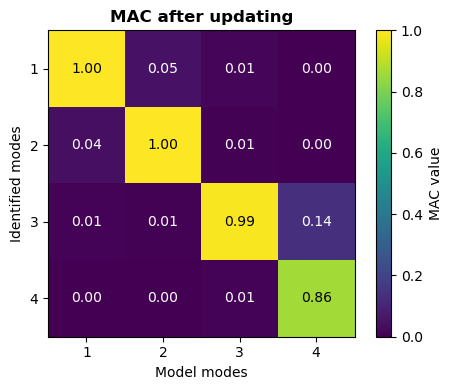

In [109]:
fdd.plot_mac(fdd.compute_mac(eigvecs_reduced, eigvecs_identified, n_modes = n_modes), title='MAC before updating', xlabel='Model modes', ylabel='Identified modes')
plt.savefig('MAC_before_updating.eps', format='eps', bbox_inches='tight')
fdd.plot_mac(fdd.compute_mac(eigvecs_new_reduced, eigvecs_identified, n_modes = n_modes), title='MAC after updating', xlabel='Model modes', ylabel='Identified modes')
plt.savefig('MAC_after_updating.eps', format='eps', bbox_inches='tight')